In [27]:
#dev imports
import subprocess
import sys
import re
import os

from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
import warnings
warnings.filterwarnings("ignore")
import multiprocessing as mp

import orbits

In [28]:
#keep imports
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from astropy import units as u
from astropy.constants import G, c

In [75]:
#Calc functions
def calc_norm(x, y, z):
    return np.sqrt(x ** 2 + y ** 2 + z ** 2)

def calc_ecc(m_tot, dx, dy, dz, dvx, dvy, dvz):
    u = m_tot * G
    v2 = dvx ** 2 + dvy ** 2 + dvz ** 2
    r = np.sqrt(dx ** 2 + dy ** 2 + dz ** 2)
    rv = dx * dvx + dy * dvy + dz * dvz
    ex = (dx * (v2 - u / r) - dvx * rv) / u
    ey = (dy * (v2 - u / r) - dvy * rv) / u
    ez = (dz * (v2 - u / r) - dvz * rv) / u
    return ex, ey, ez

def calc_sma(m_tot, dx, dy, dz, dvx, dvy, dvz):
    u = m_tot * G
    v2 = dvx ** 2 + dvy ** 2 + dvz ** 2
    r = np.sqrt(dx ** 2 + dy ** 2 + dz ** 2)
    return - u * r / (r * v2 - 2 * u)

def calc_angle(x1, y1, z1, x2, y2, z2):
    r1 = calc_norm(x1, y1, z1)
    r2 = calc_norm(x2, y2, z2)
    cos = (x1 * x2 + y1 * y2 + z1 * z2) / (r1 * r2)
    return np.arccos(cos)

def calc_L(m1, m2, dx, dy, dz, dvx, dvy, dvz):
    m_nu = m1 * m2 / (m1 + m2)
    Lx = dy * dvz - dz * dvy
    Ly = dz * dvx - dx * dvz
    Lz = dx * dvy - dy * dvx

    return m_nu * Lx, m_nu * Ly, m_nu * Lz

def get_tot_mass(data, tup):
    #get total mass of the system
    if type(tup) is int:
        return data[data["id"]==tup]["mass"][tup]
    else:
        mtot = 0

        for t in tup:
            mtot += data[data["id"]==t]["mass"][t]
        return mtot

def get_com(data, key, tup):
    mt = get_tot_mass(data, tup)

    x = 0
    y = 0
    z = 0

    for t in tup:
        x += data[data["id"]==t]['mass'] * data[data["id"]==t][key + 'x']
        y += data[data["id"]==t]['mass'] * data[data["id"]==t][key + 'y']
        z += data[data["id"]==t]['mass'] * data[data["id"]==t][key + 'z']

    return x/mt, y/mt, z/mt


def distance(data, key, i, j):
    if type(i) is int:
        xi = data[data["id"]==i][key + 'x']
        yi = data[data["id"]==i][key + 'y']
        zi = data[data["id"]==i][key + 'z']
    elif type(i) is tuple:
        xi, yi, zi = get_com(data, key, i)
    else:
        print('wrong index type of i')

    if type(j) is int:
        xj = data[data["id"]==j][key + 'x']
        yj = data[data["id"]==j][key + 'y']
        zj = data[data["id"]==j][key + 'z']
    elif type(j) is tuple:
        xj, yj, zj = get_com(data, key, j)
    else:
        print('wrong index type of j')

    return xi - xj, yi - yj, zi - zj

def add_norms(data):
    #adds norm column to output, is inplace
    p_num = data["id"].nunique()
    for i in range(p_num):
        px = data['px']
        py = data['py']
        pz = data['pz']
        data['p'] = calc_norm(px, py, pz)

        vx = data['vx']
        vy = data['vy']
        vz = data['vz']
        data['v'] = calc_norm(vx, vy, vz)

def get_ecc(data, i, j):
    mi = get_tot_mass(data, i)
    mj = get_tot_mass(data, j)
    dx, dy, dz = distance(data, 'p', i, j)
    dvx, dvy, dvz = distance(data, 'v', i, j)

    return calc_ecc(mi + mj, dx, dy, dz, dvx, dvy, dvz)

def get_sma(data, i, j):
    mi = get_tot_mass(data, i)
    mj = get_tot_mass(data, j)
    dx, dy, dz = distance(data, 'p', i, j)
    dvx, dvy, dvz = distance(data, 'v', i, j)

    return calc_sma(mi + mj, dx, dy, dz, dvx, dvy, dvz)

def get_L(data, i, j):
    mi = get_tot_mass(data, i)
    mj = get_tot_mass(data, j)
    dx, dy, dz = distance(data, 'p', i, j)
    dvx, dvy, dvz = distance(data, 'v', i, j)
    return calc_L(mi, mj, dx, dy, dz, dvx, dvy, dvz)



In [76]:
a=orbits.load_spacehub_data("tutorial/hierarchical.txt")
a[1]["mass1"]

array([1., 1., 1., ..., 1., 1., 1.], shape=(1315,))

In [77]:
df = pd.read_csv("tutorial/hierarchical.txt")
add_norms(df)
get_tot_mass(df, [0,1,2])
get_ecc(df,0,1)


(0      NaN
 1      NaN
 3      NaN
 4      NaN
 6      NaN
         ..
 3937   NaN
 3939   NaN
 3940   NaN
 3942   NaN
 3943   NaN
 Length: 2630, dtype: float64,
 0      NaN
 1      NaN
 3      NaN
 4      NaN
 6      NaN
         ..
 3937   NaN
 3939   NaN
 3940   NaN
 3942   NaN
 3943   NaN
 Length: 2630, dtype: float64,
 0      NaN
 1      NaN
 3      NaN
 4      NaN
 6      NaN
         ..
 3937   NaN
 3939   NaN
 3940   NaN
 3942   NaN
 3943   NaN
 Length: 2630, dtype: float64)

<Axes: xlabel='time', ylabel='px'>

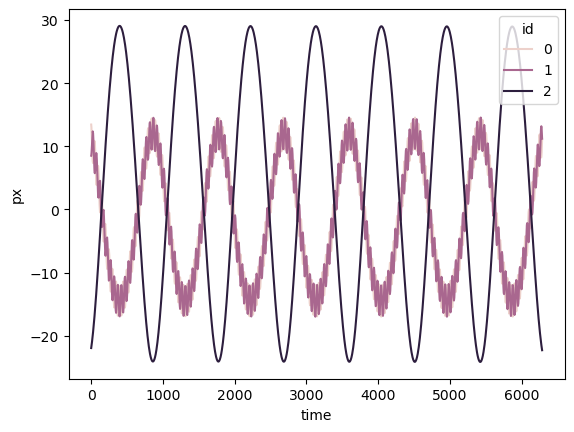

In [17]:
sns.lineplot(df, x="time", y="px", hue="id")